# **IT Helpdesk Ticket Classifier**

## Project Overview
This project builds a machine learning model that reads an IT support ticket
and automatically classifies it into a category like Hardware, Access, or HR Support.

## Tools Used
- Python, Pandas, Scikit-learn
- TF-IDF Vectorization
- Logistic Regression

## Dataset
- Source: Kaggle — IT Service Ticket Classification Dataset
- Records: ~47,000 tickets
- Columns: Document (ticket text), Topic_group (category label)

## **Step 1 — Install Kaggle and Upload API Key**
Steps to get your kaggle.json:
1. Go to https://www.kaggle.com and log in
2. Click your profile picture at top right
3. Click Settings
4. Scroll down to API section
5. Click Create New Token
6. A file called kaggle.json will download to your computer
7. Run the code cell below and upload that file

In [3]:
# Install kaggle library
!pip install kaggle --quiet

# Upload your kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fiazbhk","key":"210b25284d69b1766414b888fbd9c047"}'}

In [4]:
# Kaggle looks for the API key in a specific folder
# This code creates that folder and moves the file there

import os

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")

# Set permissions so only you can read it
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

print("Kaggle API key is ready.")

Kaggle API key is ready.


## **Step 2: Download the Dataset**
We will download the dataset directly from Kaggle using the API.
The dataset will be saved in the current Colab directory.

In [5]:
# Download the dataset from Kaggle
!kaggle datasets download -d adisongoh/it-service-ticket-classification-dataset

print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset
License(s): CC0-1.0
100% 3.45M/3.45M [00:00<00:00, 170MB/s]

Download complete.


In [6]:
import zipfile

# Unzip the downloaded file
with zipfile.ZipFile("it-service-ticket-classification-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Files extracted. Contents:")

# Show what files are inside
import os
for file in os.listdir("data"):
    print(file)

Files extracted. Contents:
all_tickets_processed_improved_v3.csv


## **Step 3: Load and Inspect the Data**
We will load the CSV file into a pandas DataFrame and look at its structure.

In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data/all_tickets_processed_improved_v3.csv")

# Show shape
print("Rows and Columns:", df.shape)

# Show column names
print("\nColumn Names:")
print(df.columns.tolist())

# Show first 3 rows
print("\nFirst 3 Rows:")
df.head(3)

Rows and Columns: (47837, 2)

Column Names:
['Document', 'Topic_group']

First 3 Rows:


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


## **Step 4: Explore the Data**
Before building the model, we need to understand what categories exist,
how many tickets are in each category, and whether any data is missing.

In [10]:
# Check how many tickets are in each category
print("Ticket count per category:")
print(df['Topic_group'].value_counts())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Ticket count per category:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

Missing values:
Document       0
Topic_group    0
dtype: int64

Data types:
Document       object
Topic_group    object
dtype: object


## **Step 5: Clean the Text Data**
Raw ticket text contains noise like extra spaces, numbers, and special characters.
We will clean the Document column so the model can learn from it properly.

In [13]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to the Document column
df['cleaned_text'] = df['Document'].apply(clean_text)

# Compare original vs cleaned for first 2 rows
print("Original:")
print(df['Document'][0][:200])
print("\nCleaned:")
print(df['cleaned_text'][0][:200])

Original:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

Cleaned:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead


## **Step 6: Convert Text to Numbers using TF-IDF**
Machine learning models cannot read raw text.
TF-IDF converts each ticket into a row of numbers based on word importance.
Words that appear too frequently everywhere (like "the", "is") get a low score.
Words that are unique to certain tickets get a higher score.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
# max_features limits vocabulary to top 10000 words
# stop_words removes common English words like the, is, and
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

# Fit and transform the cleaned text
X = tfidf.fit_transform(df['cleaned_text'])

# Target variable (what we want to predict)
y = df['Topic_group']

print("Shape of X (tickets as numbers):", X.shape)
print("Number of categories:", y.nunique())
print("Categories:", y.unique().tolist())

Shape of X (tickets as numbers): (47837, 10000)
Number of categories: 8
Categories: ['Hardware', 'Access', 'Miscellaneous', 'HR Support', 'Purchase', 'Administrative rights', 'Storage', 'Internal Project']


## **Step 7: Split Data into Training and Testing Sets**
We split the data into two parts:
- 80% Training set: the model learns from this
- 20% Testing set: we use this to check how accurate the model is

The model never sees the test set during training.
This gives us an honest measure of performance.

In [15]:
from sklearn.model_selection import train_test_split

# Split data — 80% train, 20% test
# random_state=42 makes the split the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 38269
Testing samples: 9568


## **Step 8: Train the Model**
We will use Logistic Regression as our classifier.
It is a simple, fast, and effective algorithm for text classification.

The model will look at the TF-IDF numbers for each ticket
and learn which word patterns belong to which category.

In [16]:
from sklearn.linear_model import LogisticRegression
import time

# Create the model
# max_iter=1000 gives the model enough steps to find the best solution
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model and measure how long it takes
start = time.time()
model.fit(X_train, y_train)
end = time.time()

print("Model training complete.")
print("Time taken: {:.2f} seconds".format(end - start))

Model training complete.
Time taken: 7.39 seconds


## **Step 9: Evaluate the Model**
We will test the model on the 20% test data it has never seen before.

We will look at:
- Accuracy: percentage of tickets classified correctly
- Classification Report: precision, recall, and F1 score for each category

In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy: {:.2f}%".format(accuracy * 100))

# Detailed report for each category
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 84.53%

Classification Report:
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.87      0.68      0.76       342
           HR Support       0.85      0.83      0.84      2107
             Hardware       0.79      0.88      0.83      2760
     Internal Project       0.91      0.80      0.86       451
        Miscellaneous       0.80      0.82      0.81      1400
             Purchase       0.97      0.88      0.92       497
              Storage       0.93      0.84      0.88       556

             accuracy                           0.85      9568
            macro avg       0.88      0.82      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



## **Step 10: Confusion Matrix**
A confusion matrix shows where the model made mistakes.
Each row is the actual category and each column is what the model predicted.
Numbers on the diagonal are correct predictions.
Numbers off the diagonal are mistakes.

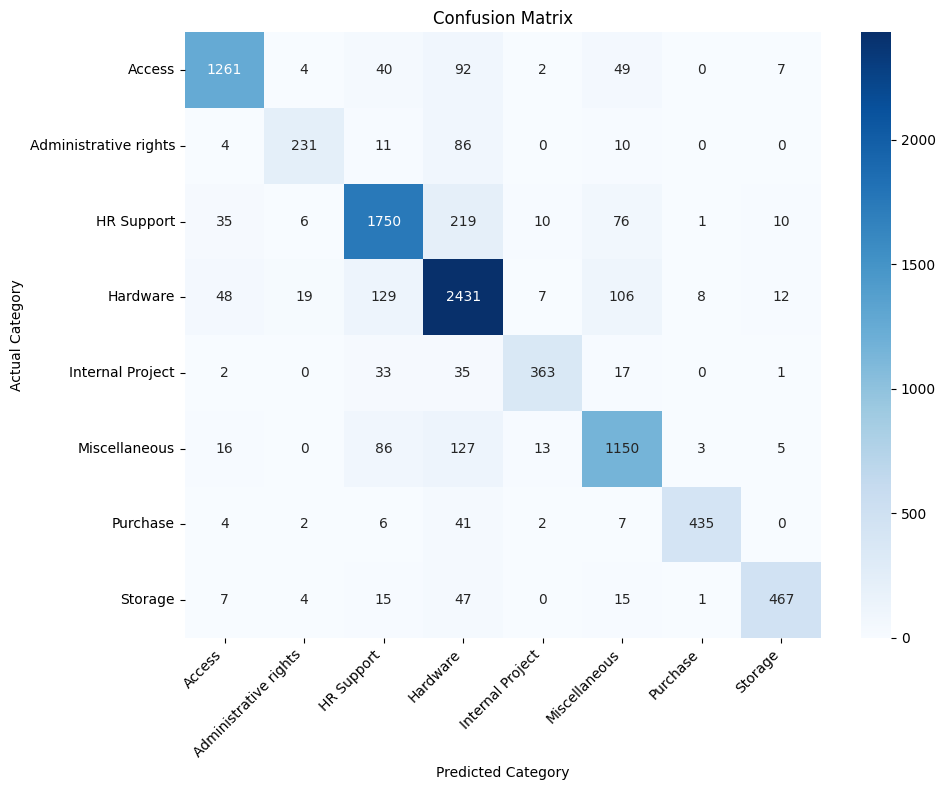

Confusion matrix saved.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title('Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved.")

## **Step 11: Test the Model on New Tickets**
Now we will write our own ticket text and see what category the model predicts.
This is what the model would do in a real IT helpdesk system.

In [19]:
# Write your own ticket text here and test the model

my_tickets = [
    "My laptop screen is broken and I cannot turn it on",
    "I need access to the HR portal to submit my leave request",
    "Please give me admin rights to install software on my computer",
    "My external hard drive is not showing up on the network storage",
    "I want to purchase a new keyboard and mouse for my workstation"
]

# Clean and vectorize the new tickets
my_tickets_cleaned = [clean_text(ticket) for ticket in my_tickets]
my_tickets_vectorized = tfidf.transform(my_tickets_cleaned)

# Predict categories
predictions = model.predict(my_tickets_vectorized)

# Show results
print("Ticket Predictions:\n")
for ticket, prediction in zip(my_tickets, predictions):
    print("Ticket  :", ticket)
    print("Category:", prediction)
    print()

Ticket Predictions:

Ticket  : My laptop screen is broken and I cannot turn it on
Category: Hardware

Ticket  : I need access to the HR portal to submit my leave request
Category: HR Support

Ticket  : Please give me admin rights to install software on my computer
Category: Administrative rights

Ticket  : My external hard drive is not showing up on the network storage
Category: Storage

Ticket  : I want to purchase a new keyboard and mouse for my workstation
Category: Hardware



## **Step 12 - Save Model and Vectorizer**

In [22]:
# Check if tfidf is fitted properly
print(type(tfidf))
print("Vocabulary size:", len(tfidf.vocabulary_))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Vocabulary size: 10000


In [23]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved successfully.")

Saved successfully.


In [24]:
from google.colab import files

files.download("model.pkl")
files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Project Summary**

### **What We Built**
A machine learning model that automatically classifies IT helpdesk tickets
into 8 categories: Hardware, HR Support, Access, Miscellaneous,
Storage, Purchase, Internal Project, and Administrative rights.

### **Steps Completed**
1. Downloaded dataset from Kaggle using the API
2. Loaded and explored 47,837 real IT support tickets
3. Cleaned and preprocessed the ticket text
4. Converted text to numbers using TF-IDF Vectorization
5. Split data into 80% training and 20% testing sets
6. Trained a Logistic Regression classifier
7. Achieved 84.53% accuracy on unseen test data
8. Visualized results using a confusion matrix
9. Tested the model on custom ticket text

### **Results**
| Category              | Precision | Recall | F1 Score |
|-----------------------|-----------|--------|----------|
| Access                | 0.92      | 0.87   | 0.89     |
| Administrative rights | 0.87      | 0.68   | 0.76     |
| HR Support            | 0.85      | 0.83   | 0.84     |
| Hardware              | 0.79      | 0.88   | 0.83     |
| Internal Project      | 0.91      | 0.80   | 0.86     |
| Miscellaneous         | 0.80      | 0.82   | 0.81     |
| Purchase              | 0.97      | 0.88   | 0.92     |
| Storage               | 0.93      | 0.84   | 0.88     |
| Overall Accuracy      |           |        | 84.53%   |

### **Tools and Libraries**
- Python, Pandas, Scikit-learn, Matplotlib, Seaborn
- TF-IDF Vectorization, Logistic Regression

### **Dataset**
- Source: Kaggle — IT Service Ticket Classification Dataset by adisongoh
- Link: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset

In [25]:
import sklearn
print(sklearn.__version__)

1.6.1
